In [ ]:
import os
import random
from PIL import Image
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

AttributeError: partially initialized module 'torch._inductor' from 'c:\Users\Stasy\Desktop\учёба\AI_Architecture\venv\Lib\site-packages\torch\_inductor\__init__.py' has no attribute 'custom_graph_pass' (most likely due to a circular import)

In [2]:
import os
import random
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader

class TinyImageNetDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None, num_classes=10):
        """
        root_dir: путь до папки tiny-imagenet-200
        split: 'train', 'val' или 'test'
        transform: трансформации изображений
        num_classes: количество случайных классов для выборки
        """
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.num_classes = num_classes

        # Чтение всех классов
        with open(os.path.join(root_dir, 'wnids.txt'), 'r') as f:
            self.class_names = [line.strip() for line in f]

        # Выбираем случайные 10 классов
        self.selected_classes = random.sample(self.class_names, self.num_classes)
        self.class_to_idx = {name: i for i, name in enumerate(self.selected_classes)}

        self.samples = []
        if split == 'train':
            train_dir = os.path.join(root_dir, 'train')
            for cls in self.selected_classes:
                img_dir = os.path.join(train_dir, cls, 'images')
                if not os.path.exists(img_dir):
                    continue
                for img_name in os.listdir(img_dir):
                    img_path = os.path.join(img_dir, img_name)
                    label = self.class_to_idx[cls]
                    self.samples.append((img_path, label))

        elif split == 'val':
            val_dir = os.path.join(root_dir, 'val', 'images')
            anno_path = os.path.join(root_dir, 'val', 'val_annotations.txt')

            label_map = {}
            with open(anno_path, 'r') as f:
                for line in f:
                    img_name, cls, *_ = line.strip().split('\t')
                    label_map[img_name] = cls

            for img_name in os.listdir(val_dir):
                cls = label_map.get(img_name)
                if cls in self.selected_classes:
                    img_path = os.path.join(val_dir, img_name)
                    label = self.class_to_idx[cls]
                    self.samples.append((img_path, label))

        else:  # Test
            test_dir = os.path.join(root_dir, 'test', 'images')
            for img_name in os.listdir(test_dir):
                img_path = os.path.join(test_dir, img_name)
                self.samples.append((img_path, -1))  # тест без меток

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


train_transform = transforms.Compose([
    transforms.Resize((72, 72)),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

root = "tiny-imagenet-200"

# Обучающий и валидационный датасеты
train_dataset = TinyImageNetDataset(root, split='train', transform=train_transform)
val_dataset = TinyImageNetDataset(root, split='val', transform=val_transform)

# Загрузчики данных
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

# Вывод статистики
print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Классов: {len(train_dataset.selected_classes)}")


Train size: 5000
Val size: 500
Классов: 10


In [3]:
def print_cls_names(root_dir):
    print("Выбранные классы:")
    with open(os.path.join(root_dir, 'words.txt'), 'r') as f:
        words_strings = [line.strip() for line in f]
        for cls in train_dataset.selected_classes:
            for line in words_strings:
                if line.startswith(cls):
                    print(f"{cls}: {line}")
                    break
print_cls_names(root)

Выбранные классы:
n03444034: n03444034	go-kart
n07614500: n07614500	ice cream, icecream
n02802426: n02802426	basketball
n02788148: n02788148	bannister, banister, balustrade, balusters, handrail
n02988304: n02988304	CD player
n04456115: n04456115	torch
n02481823: n02481823	chimpanzee, chimp, Pan troglodytes
n02058221: n02058221	albatross, mollymawk
n07720875: n07720875	bell pepper
n03085013: n03085013	computer keyboard, keypad


In [4]:
def print_cls_name_from_code(root_dir,code_name):
    print("Название класса:")
    with open(os.path.join(root_dir, 'words.txt'), 'r') as f:
        words_strings = [line.strip() for line in f]
        for line in words_strings:
            if line.startswith(code_name):
                print(f"{line}")
                break

In [ ]:
# import torch
# import matplotlib.pyplot as plt
# import time

# timeout = 60  # Максимальное время ожидания в секундах
# start_time = time.time()

# while time.time() - start_time < timeout:
#     try:
#         images, labels = next(iter(train_loader))
#         break
#     except StopIteration:
#         print("Ошибка в загрузке данных или итерации")
#         break
#     if time.time() - start_time > timeout:
#         print("Превышено время ожидания. Прерываю выполнение.")
#         break

# def denormalize(img_tensor):
#     """Вернём изображение из нормализованного диапазона в [0,1]"""
#     mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 1, 3)
#     std = torch.tensor([0.229, 0.224, 0.225]).view(1, 1, 3)
#     img = img_tensor.permute(1, 2, 0) * std + mean
#     return img.clamp(0, 1)

# images_vis = images.permute(0, 2, 3, 1)

# images_vis = torch.stack([denormalize(img) for img in images])

# plt.figure(figsize=(12, 6))
# for i in range(8):
#     plt.subplot(2, 4, i+1)
#     plt.imshow(images_vis[i])
#     plt.title(f"Class: {labels[i].item()}")
#     plt.axis('off')
# plt.suptitle("Примеры изображений из Tiny ImageNet (с аугментациями)", fontsize=16)
# plt.tight_layout()
# plt.show()

# print(f"Размер батча: {images.shape}")
# print(f"Диапазон значений: [{images.min():.3f}, {images.max():.3f}]")
# print(f"Метки классов: {labels.tolist()}")
# print(f"Всего классов в датасете: {len(train_dataset.class_names)}")
# print(f"Примеры названий классов: {train_dataset.class_names[:5]}")

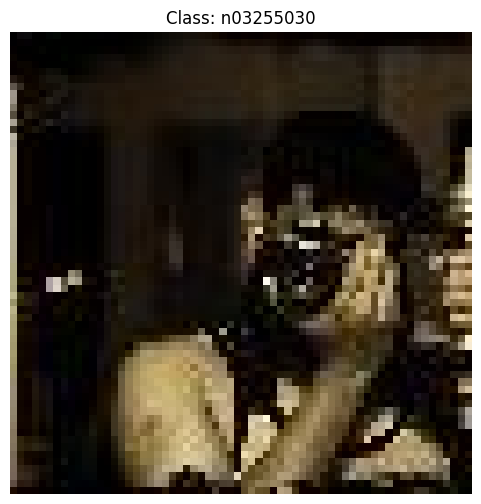

Размер изображения: torch.Size([1, 3, 64, 64])
Метка класса: 2
Название класса:
n03255030	dumbbell


In [5]:
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader

# Преобразования
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Изменяем размер изображения
    transforms.ToTensor(),        # Преобразуем изображение в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Нормализуем
])

# Инициализация датасета и DataLoader
root = "tiny-imagenet-200"
train_dataset = TinyImageNetDataset(root, split='train', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)  # Установим batch_size=1

# Получаем одно изображение и метку
images, labels = next(iter(train_loader))

# Денормализация для отображения
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 1, 3)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 1, 3)
    img = img_tensor.permute(1, 2, 0) * std + mean
    return img.clamp(0, 1)

# Денормализуем изображение
img_vis = denormalize(images[0])

# Визуализация одного изображения
plt.figure(figsize=(6, 6))
plt.imshow(img_vis.numpy())  # Переходим от тензора к NumPy для matplotlib
class_name = train_dataset.selected_classes[labels.item()]  # Получаем имя класса по индексу
plt.title(f"Class: {class_name}")  # Печатаем название класса
plt.axis('off')  # Убираем оси
plt.show()

print(f"Размер изображения: {images.shape}")
print(f"Метка класса: {labels.item()}")  # Выводим индекс метки
print_cls_name_from_code(root,class_name)  # Выводим название класса


In [ ]:
from collections import Counter, defaultdict
import numpy as np

print(" Метод 1: Простая случайная стратификация")

train_dataset = TinyImageNetDataset(root, split='train', transform=train_transform)
all_samples = train_dataset.samples

print(f" Всего образцов: {len(all_samples)}")

random.seed(42)
all_samples_copy = all_samples.copy()
random.shuffle(all_samples_copy)

val_fraction = 0.2
split_idx = int(len(all_samples_copy) * (1 - val_fraction))
train_split_random = all_samples_copy[:split_idx]
val_split_random = all_samples_copy[split_idx:]

print(f" Случайное разделение:")
print(f"   Train: {len(train_split_random)} образцов")
print(f"   Val: {len(val_split_random)} образцов")

def analyze_class_distribution(samples, name):
    labels = [label for _, label in samples]
    class_counts = Counter(labels)
    print(f" {name} - распределение классов:")
    print(f"   Минимум: {min(class_counts.values())}")
    print(f"   Максимум: {max(class_counts.values())}")
    print(f"   Среднее: {np.mean(list(class_counts.values())):.1f}")
    print(f"   Стандартное отклонение: {np.std(list(class_counts.values())):.1f}")

analyze_class_distribution(train_split_random, "Случайное train")
analyze_class_distribution(val_split_random, "Случайное val")


 Метод 1: Простая случайная стратификация
 Всего образцов: 5000
 Случайное разделение:
   Train: 4000 образцов
   Val: 1000 образцов
 Случайное train - распределение классов:
   Минимум: 388
   Максимум: 418
   Среднее: 400.0
   Стандартное отклонение: 9.5
 Случайное val - распределение классов:
   Минимум: 82
   Максимум: 112
   Среднее: 100.0
   Стандартное отклонение: 9.5


In [7]:
# Заполните пропуски в BasicBlock
class BasicBlock(nn.Module):
    """
    Базовый блок ResNet с residual connection

    Args:
        in_channels (int): количество входных каналов
        out_channels (int): количество выходных каналов
        stride (int): шаг свертки (по умолчанию 1)
        downsample (nn.Module): слой для изменения размерности (если нужно)
    """
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample


    def forward(self, x):
        idenity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # Вторая свертка
        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            idenity = self.downsample(x)

        out += idenity
        out = self.relu(out)

        return out

# basic_block = BasicBlock(64, 64, stride=2, downsample=nn.Sequential(
#     nn.Conv2d(64, 64, kernel_size=1, stride=2),
#     nn.BatchNorm2d(64)
# ))

# # Тестовый вход: 2 изображения размером 64x32x32
# test_input = torch.randn(2, 64, 32, 32)

# # Применяем блок
# output = basic_block(test_input)
# print(output.shape)

In [8]:
class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64  # Инициализируем in_channels

        # Первый слой: Conv2d + BatchNorm + ReLU + MaxPool
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Layer1: 2x Basic Block с 64 каналами
        self.layer1 = self._make_layer(64, 2, stride=1)

        # Layer2: 2x Basic Block с 128 каналами
        self.layer2 = self._make_layer(128, 2, stride=2)

        # Layer3: 2x Basic Block с 256 каналами
        self.layer3 = self._make_layer(256, 2, stride=2)

        # Layer4: 2x Basic Block с 512 каналами
        self.layer4 = self._make_layer(512, 2, stride=2)

        # Global Average Pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Полносвязный слой для классификации (10 классов)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            layers.append(BasicBlock(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


In [9]:
# Вариант A: 32 -> 64 -> 128 -> 256
class ResNet18_A(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(32, 2, stride=1)
        self.layer2 = self._make_layer(64, 2, stride=2)
        self.layer3 = self._make_layer(128, 2, stride=2)
        self.layer4 = self._make_layer(256, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

        layers = [BasicBlock(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

# Вариант B: 64 -> 128 -> 256 (без 4-го слоя)
class ResNet18_B(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

        layers = [BasicBlock(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


In [10]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

def train_epoch(model, data_loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in data_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(data_loader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


def validate_epoch(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(data_loader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


In [11]:
import matplotlib.pyplot as plt

def train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, num_epochs, device, plotting=False):
    best_val_acc = 0.0

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

        # Сохраняем метрики для графиков
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # Логирование
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')  # Сохранение модели

    # Построение графиков
    if not plotting:
        plot_metrics(train_accuracies, val_accuracies, train_losses, val_losses)

    print("Training complete.")

def plot_metrics(train_accuracies, val_accuracies, train_losses, val_losses):
    epochs = range(1, len(train_accuracies) + 1)

    plt.figure(figsize=(12, 6))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_accuracies, label='Train Accuracy')
    plt.plot(epochs, val_accuracies, label='Val Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()



In [12]:
def print_model_info(model):
    # Количество параметров
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params}")

    # Архитектура модели
    print("\nModel Architecture:")
    print(model)



In [13]:
def plot_2_models_metrics(model_A, model_B):
    # Here, we assume that train_loss, val_loss, train_accuracy, and val_accuracy
    # are stored from the training process in the respective model objects.
    plt.figure(figsize=(15, 10))

    # Plot Training Loss
    plt.subplot(2, 4, 1)
    plt.plot(model_A.train_loss, label="Model A Train Loss")
    plt.plot(model_B.train_loss, label="Model B Train Loss")
    plt.title("Training Loss")
    plt.legend()

    # Plot Validation Loss
    plt.subplot(2, 4, 2)
    plt.plot(model_A.val_loss, label="Model A Validation Loss")
    plt.plot(model_B.val_loss, label="Model B Validation Loss")
    plt.title("Validation Loss")
    plt.legend()

    # Plot Training Accuracy
    plt.subplot(2, 4, 3)
    plt.plot(model_A.train_accuracy, label="Model A Train Accuracy")
    plt.plot(model_B.train_accuracy, label="Model B Train Accuracy")
    plt.title("Training Accuracy")
    plt.legend()

    # Plot Validation Accuracy
    plt.subplot(2, 4, 4)
    plt.plot(model_A.val_accuracy, label="Model A Validation Accuracy")
    plt.plot(model_B.val_accuracy, label="Model B Validation Accuracy")
    plt.title("Validation Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


In [14]:
import torch.optim as optim

def train_and_compare_models(train_loader, val_loader, num_classes=10, epochs=20):
    # Create both models
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model_A = ResNet18_A(num_classes=num_classes).to(device)
    model_B = ResNet18_B(num_classes=num_classes).to(device)

    # Define optimizers and loss functions
    optimizer_A = optim.Adam(model_A.parameters(), lr=0.001)
    optimizer_B = optim.Adam(model_B.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # Train models
    train_and_evaluate(model_A, train_loader, val_loader, optimizer_A, criterion, num_epochs=epochs, device=device, plotting=True)
    train_and_evaluate(model_B, train_loader, val_loader, optimizer_B, criterion, num_epochs=epochs, device=device, plotting=True)

    # Print model comparison results
    print(f"Model A - Number of parameters: {sum(p.numel() for p in model_A.parameters())}")
    print(f"Model B - Number of parameters: {sum(p.numel() for p in model_B.parameters())}")

    # Plot metrics for both models
    plot_2_models_metrics(model_A, model_B)

    return model_A, model_B


Epoch 1/20
Train Loss: 2.3859, Train Accuracy: 0.1370
Val Loss: 3.4800, Val Accuracy: 0.0640
Epoch 2/20
Train Loss: 2.1464, Train Accuracy: 0.2368
Val Loss: 2.8599, Val Accuracy: 0.0620
Epoch 3/20
Train Loss: 1.9435, Train Accuracy: 0.3134
Val Loss: 2.6451, Val Accuracy: 0.1100
Epoch 4/20
Train Loss: 1.7675, Train Accuracy: 0.3842
Val Loss: 2.6384, Val Accuracy: 0.0920
Epoch 5/20
Train Loss: 1.5694, Train Accuracy: 0.4484
Val Loss: 2.8915, Val Accuracy: 0.0840
Epoch 6/20
Train Loss: 1.3860, Train Accuracy: 0.5172
Val Loss: 2.5108, Val Accuracy: 0.0800
Epoch 7/20
Train Loss: 1.1549, Train Accuracy: 0.6010
Val Loss: 3.5319, Val Accuracy: 0.1100
Epoch 8/20
Train Loss: 0.9059, Train Accuracy: 0.6808
Val Loss: 3.2966, Val Accuracy: 0.1020
Epoch 9/20
Train Loss: 0.6277, Train Accuracy: 0.7812
Val Loss: 3.5496, Val Accuracy: 0.1080
Epoch 10/20
Train Loss: 0.4063, Train Accuracy: 0.8620
Val Loss: 3.8478, Val Accuracy: 0.1340
Epoch 11/20
Train Loss: 0.2486, Train Accuracy: 0.9152
Val Loss: 4.85

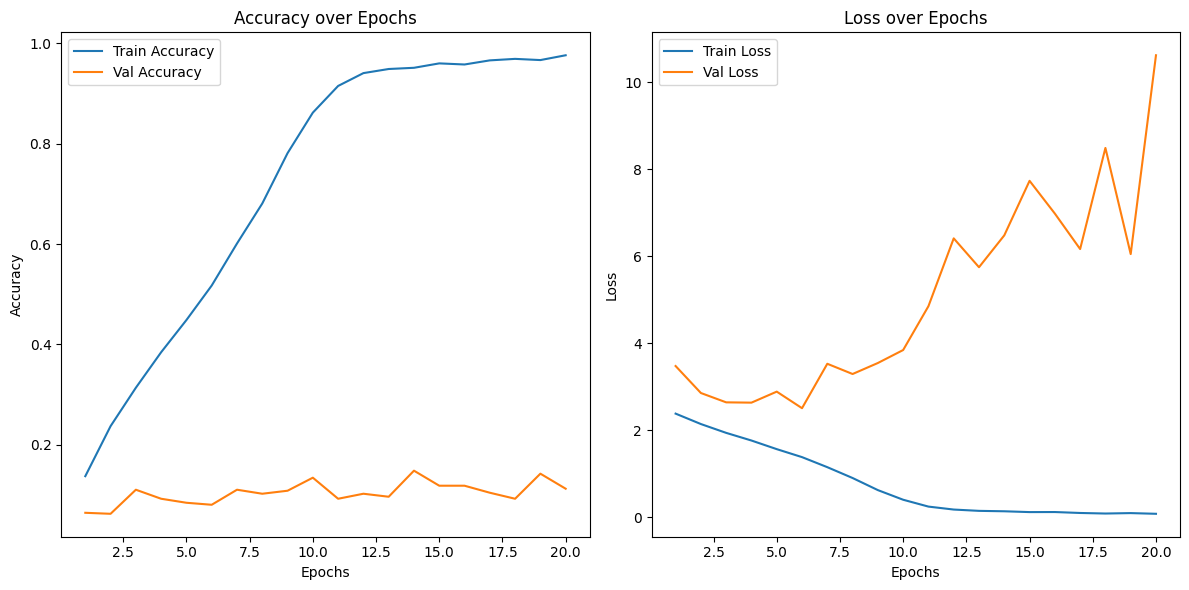

Training complete.
Total parameters: 11186442

Model Architecture:
ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): 

In [15]:
#BASE RESNET18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Модель, оптимизатор и loss функция
model = ResNet18(num_classes=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

# Обучение и валидация
train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, num_epochs=20, device=device)

# Вывод информации о модели
print_model_info(model)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np

# Define the models
class ModelA(nn.Module):
    def __init__(self, num_classes=10):
        super(ModelA, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = x.view(-1, 256 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


class ModelB(nn.Module):
    def __init__(self, num_classes=10):
        super(ModelB, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 256 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# Function to calculate the number of parameters in the model
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Training and evaluation functions
def train_and_compare_models(train_loader, val_loader, num_classes=10, epochs=20):
    model_A = ModelA(num_classes=num_classes)
    model_B = ModelB(num_classes=num_classes)
    
    # Set up the optimizer and loss function
    criterion = nn.CrossEntropyLoss()
    optimizer_A = optim.Adam(model_A.parameters(), lr=0.001)
    optimizer_B = optim.Adam(model_B.parameters(), lr=0.001)
    
    # Training loop
    def train(model, optimizer, data_loader):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in data_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        return running_loss / len(data_loader), 100 * correct / total

    # Train both models
    train_loss_A, train_acc_A = train(model_A, optimizer_A, train_loader)
    train_loss_B, train_acc_B = train(model_B, optimizer_B, train_loader)
    
    # Validation loop
    def validate(model, data_loader):
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in data_loader:
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        return 100 * correct / total

    val_acc_A = validate(model_A, val_loader)
    val_acc_B = validate(model_B, val_loader)
    
    # Print results
    print(f"Model A: Train Accuracy: {train_acc_A:.2f}% | Validation Accuracy: {val_acc_A:.2f}%")
    print(f"Model B: Train Accuracy: {train_acc_B:.2f}% | Validation Accuracy: {val_acc_B:.2f}%")
    
    # Compare the number of parameters
    params_A = count_parameters(model_A)
    params_B = count_parameters(model_B)
    print(f"Model A Parameters: {params_A}")
    print(f"Model B Parameters: {params_B}")
    
    return model_A, model_B, val_acc_A, val_acc_B


# Example usage
# Assuming `train_loader` and `val_loader` are already defined in the previous cells
model_A, model_B, val_acc_A, val_acc_B = train_and_compare_models(train_loader, val_loader, num_classes=10, epochs=20)

# You can visualize the training results with plots if needed
# Placeholder for the graphs that compare validation accuracy and loss


KeyboardInterrupt: 

Task 3.2

ЗАПУСК ЭКСПЕРИМЕНТА 3.2: ВЛИЯНИЕ КОЛИЧЕСТВА RESIDUAL БЛОКОВ
Using device: cuda
=== Создание моделей ===
ResNet-A [1,1,1,1]: 4,913,802 параметров, 4 блоков
ResNet-B [2,2,2,2]: 11,186,442 параметров, 8 блоков
ResNet-C [3,3,3,3]: 17,459,082 параметров, 12 блоков

=== Обучение моделей ===

--- Обучение ResNet-A [1,1,1,1] ---
Epoch 5/20: Train Acc: 0.5812, Val Acc: 0.0880
Epoch 10/20: Train Acc: 0.9514, Val Acc: 0.0800
Epoch 15/20: Train Acc: 0.9728, Val Acc: 0.0980
Epoch 20/20: Train Acc: 0.9776, Val Acc: 0.0800
Лучшая Val Accuracy: 0.1240 на эпохе 1

--- Обучение ResNet-B [2,2,2,2] ---
Epoch 5/20: Train Acc: 0.3946, Val Acc: 0.1040
Epoch 10/20: Train Acc: 0.8090, Val Acc: 0.1100
Epoch 15/20: Train Acc: 0.9540, Val Acc: 0.1240
Epoch 20/20: Train Acc: 0.9698, Val Acc: 0.1280
Лучшая Val Accuracy: 0.1640 на эпохе 16

--- Обучение ResNet-C [3,3,3,3] ---
Epoch 5/20: Train Acc: 0.2922, Val Acc: 0.0820
Epoch 10/20: Train Acc: 0.5746, Val Acc: 0.1000
Epoch 15/20: Train Acc: 0.9232, Val Acc: 0.1300

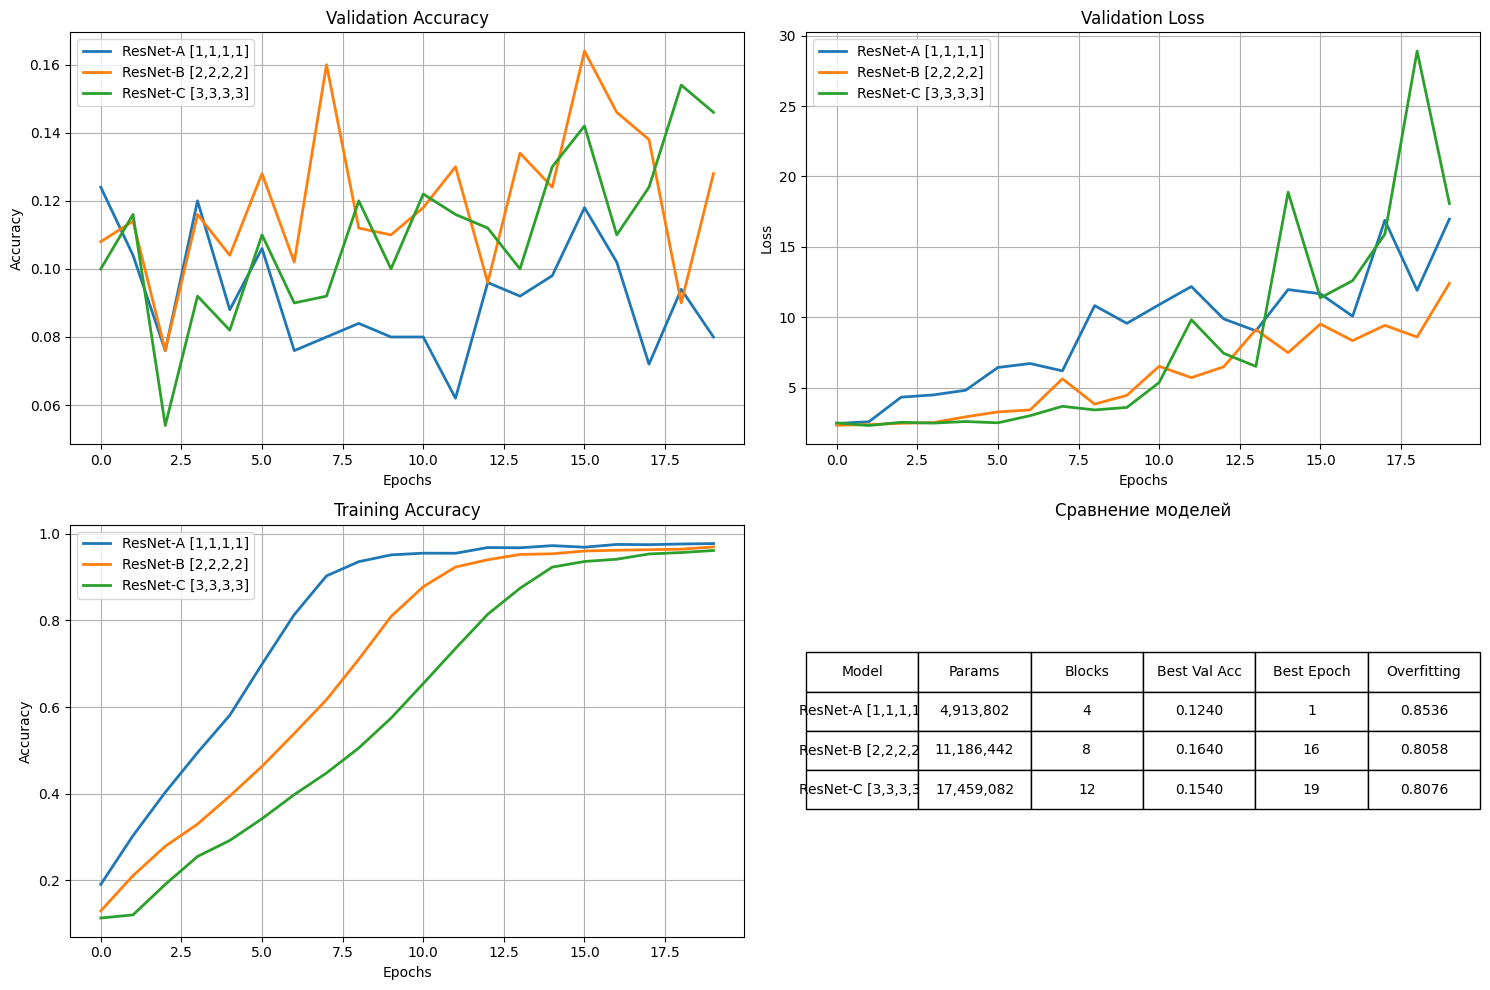


=== АНАЛИЗ РЕЗУЛЬТАТОВ ===
Сравнение моделей:
--------------------------------------------------------------------------------
Model                Params       Blocks   Best Val Acc Best Epoch Overfitting
--------------------------------------------------------------------------------
ResNet-A [1,1,1,1]   4,913,802    4        0.1240       1          0.8536    
ResNet-B [2,2,2,2]   11,186,442   8        0.1640       16         0.8058    
ResNet-C [3,3,3,3]   17,459,082   12       0.1540       19         0.8076    
--------------------------------------------------------------------------------
Оптимальная модель: ResNet-B [2,2,2,2]
Лучшая точность: 0.1640

=== АНАЛИЗ ПЕРЕОБУЧЕНИЯ ===
⚠️  ResNet-A [1,1,1,1]: ВЫСОКОЕ переобучение (0.8536)
⚠️  ResNet-B [2,2,2,2]: ВЫСОКОЕ переобучение (0.8058)
⚠️  ResNet-C [3,3,3,3]: ВЫСОКОЕ переобучение (0.8076)


In [21]:
# Кастомная ResNet с настраиваемым количеством блоков
# 1. Модифицируем BasicBlock для работы с разным количеством блоков
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

# 2. ResNet с настраиваемым количеством блоков
class ResNetDepth(nn.Module):
    def __init__(self, num_classes=10, blocks_per_layer=[2, 2, 2, 2]):
        super().__init__()
        self.in_channels = 64

        # Первые слои одинаковые для всех вариантов
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Слои с разным количеством блоков (используем лучшую конфигурацию каналов из 3.1)
        self.layer1 = self._make_layer(64, blocks_per_layer[0], stride=1)
        self.layer2 = self._make_layer(128, blocks_per_layer[1], stride=2)
        self.layer3 = self._make_layer(256, blocks_per_layer[2], stride=2)
        self.layer4 = self._make_layer(512, blocks_per_layer[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        # Сохраняем информацию о количестве блоков для анализа
        self.blocks_per_layer = blocks_per_layer
        self.total_blocks = sum(blocks_per_layer)

    def _make_layer(self, out_channels, num_blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            layers.append(BasicBlock(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

# 3. Функции обучения (используем существующие, но модифицируем для сохранения метрик)
def train_epoch_with_history(model, data_loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in data_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(data_loader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc

def validate_epoch_with_history(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(data_loader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc

# 4. Главная функция для эксперимента 3.2
def run_depth_experiment_3_2(train_loader, val_loader, num_classes=10, epochs=20):
    """Запуск эксперимента с различным количеством residual блоков"""

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Создаем три варианта моделей
    models_config = {
        'ResNet-A [1,1,1,1]': [1, 1, 1, 1],  # 4 блока
        'ResNet-B [2,2,2,2]': [2, 2, 2, 2],  # 8 блоков (стандартная ResNet18)
        'ResNet-C [3,3,3,3]': [3, 3, 3, 3],  # 12 блоков
    }

    # Словари для хранения результатов
    models = {}
    results = {}

    print("=== Создание моделей ===")
    for name, blocks in models_config.items():
        model = ResNetDepth(num_classes=num_classes, blocks_per_layer=blocks)
        models[name] = model
        num_params = sum(p.numel() for p in model.parameters())
        print(f"{name}: {num_params:,} параметров, {model.total_blocks} блоков")

    print("\n=== Обучение моделей ===")

    # Обучаем каждую модель
    for name, model in models.items():
        print(f"\n--- Обучение {name} ---")

        # Перемещаем модель на устройство
        model = model.to(device)

        # Оптимизатор и функция потерь
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        criterion = torch.nn.CrossEntropyLoss()

        # Списки для хранения метрик
        train_losses = []
        val_losses = []
        train_accuracies = []
        val_accuracies = []

        best_val_acc = 0.0
        best_epoch = 0

        for epoch in range(epochs):
            # Обучение
            train_loss, train_acc = train_epoch_with_history(model, train_loader, optimizer, criterion, device)
            # Валидация
            val_loss, val_acc = validate_epoch_with_history(model, val_loader, criterion, device)

            # Сохраняем метрики
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accuracies.append(train_acc)
            val_accuracies.append(val_acc)

            # Проверяем лучшую accuracy
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_epoch = epoch + 1

            if (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1}/{epochs}: Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

        # Сохраняем результаты
        results[name] = {
            'model': model,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accuracies': train_accuracies,
            'val_accuracies': val_accuracies,
            'best_val_acc': best_val_acc,
            'best_epoch': best_epoch,
            'num_params': sum(p.numel() for p in model.parameters()),
            'total_blocks': model.total_blocks
        }

        print(f"Лучшая Val Accuracy: {best_val_acc:.4f} на эпохе {best_epoch}")

    # 5. Визуализация результатов
    print("\n=== Визуализация результатов ===")

    plt.figure(figsize=(15, 10))

    # График Accuracy
    plt.subplot(2, 2, 1)
    for name, result in results.items():
        plt.plot(result['val_accuracies'], label=name, linewidth=2)
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # График Loss
    plt.subplot(2, 2, 2)
    for name, result in results.items():
        plt.plot(result['val_losses'], label=name, linewidth=2)
    plt.title('Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # График Training Accuracy
    plt.subplot(2, 2, 3)
    for name, result in results.items():
        plt.plot(result['train_accuracies'], label=name, linewidth=2)
    plt.title('Training Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Сравнительная таблица
    plt.subplot(2, 2, 4)
    # Создаем таблицу с результатами
    table_data = []
    for name, result in results.items():
        overfitting = max(result['train_accuracies']) - result['best_val_acc']
        table_data.append([
            name,
            f"{result['num_params']:,}",
            f"{result['total_blocks']}",
            f"{result['best_val_acc']:.4f}",
            f"{result['best_epoch']}",
            f"{overfitting:.4f}"
        ])

    # Создаем таблицу
    table = plt.table(cellText=table_data,
                     colLabels=['Model', 'Params', 'Blocks', 'Best Val Acc', 'Best Epoch', 'Overfitting'],
                     loc='center',
                     cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    plt.axis('off')
    plt.title('Сравнение моделей')

    plt.tight_layout()
    plt.show()

    # 6. Анализ результатов
    print("\n=== АНАЛИЗ РЕЗУЛЬТАТОВ ===")
    print("Сравнение моделей:")
    print("-" * 80)
    print(f"{'Model':<20} {'Params':<12} {'Blocks':<8} {'Best Val Acc':<12} {'Best Epoch':<10} {'Overfitting':<10}")
    print("-" * 80)

    best_model = None
    best_accuracy = 0

    for name, result in results.items():
        overfitting = max(result['train_accuracies']) - result['best_val_acc']
        print(f"{name:<20} {result['num_params']:<12,} {result['total_blocks']:<8} {result['best_val_acc']:<12.4f} {result['best_epoch']:<10} {overfitting:<10.4f}")

        if result['best_val_acc'] > best_accuracy:
            best_accuracy = result['best_val_acc']
            best_model = name

    print("-" * 80)
    print(f"Оптимальная модель: {best_model}")
    print(f"Лучшая точность: {best_accuracy:.4f}")

    # Анализ переобучения
    print("\n=== АНАЛИЗ ПЕРЕОБУЧЕНИЯ ===")
    for name, result in results.items():
        overfitting = max(result['train_accuracies']) - result['best_val_acc']
        if overfitting > 0.1:
            print(f"⚠️  {name}: ВЫСОКОЕ переобучение ({overfitting:.4f})")
        elif overfitting > 0.05:
            print(f"⚠️  {name}: Умеренное переобучение ({overfitting:.4f})")
        else:
            print(f"✅ {name}: Низкое переобучение ({overfitting:.4f})")

    return results

# 7. Запуск эксперимента
print("ЗАПУСК ЭКСПЕРИМЕНТА 3.2: ВЛИЯНИЕ КОЛИЧЕСТВА RESIDUAL БЛОКОВ")
results = run_depth_experiment_3_2(train_loader, val_loader, num_classes=10, epochs=20)

Task 3.3

In [ ]:
# 1. Модифицируем BasicBlock для поддержки разных функций активации
class BasicBlockWithActivation(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None, activation='relu'):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

        # Выбор функции активации
        if activation == 'relu':
            self.activation = nn.ReLU(inplace=True)
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(0.1, inplace=True)
        elif activation == 'elu':
            self.activation = nn.ELU(inplace=True)
        elif activation == 'gelu':
            self.activation = nn.GELU()
        else:
            raise ValueError(f"Unknown activation: {activation}")

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.activation(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.activation(out)

        return out

# 2. ResNet с настраиваемой функцией активации
class ResNetActivation(nn.Module):
    def __init__(self, num_classes=10, blocks_per_layer=[2, 2, 2, 2], activation='relu'):
        super().__init__()
        self.in_channels = 64
        self.activation_name = activation

        # Первые слои
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)

        # Выбор активации для первых слоев
        if activation == 'relu':
            self.activation = nn.ReLU(inplace=True)
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(0.1, inplace=True)
        elif activation == 'elu':
            self.activation = nn.ELU(inplace=True)
        elif activation == 'gelu':
            self.activation = nn.GELU()

        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Слои с выбранной активацией
        self.layer1 = self._make_layer(64, blocks_per_layer[0], stride=1, activation=activation)
        self.layer2 = self._make_layer(128, blocks_per_layer[1], stride=2, activation=activation)
        self.layer3 = self._make_layer(256, blocks_per_layer[2], stride=2, activation=activation)
        self.layer4 = self._make_layer(512, blocks_per_layer[3], stride=2, activation=activation)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride, activation):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(BasicBlockWithActivation(self.in_channels, out_channels, stride, downsample, activation))
        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            layers.append(BasicBlockWithActivation(self.in_channels, out_channels, activation=activation))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.activation(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

# 3. Функции для обучения (аналогичные предыдущим, но с сохранением истории)
def train_model_with_activation(model, train_loader, val_loader, optimizer, criterion, device, epochs=20, model_name=""):
    """Обучение модели с сохранением метрик"""

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_val_acc = 0.0
    best_epoch = 0

    print(f"Обучение {model_name}...")

    for epoch in range(epochs):
        # Обучение
        model.train()
        running_loss = 0.0
        train_preds = []
        train_labels = []

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)

        # Валидация
        val_loss, val_acc = validate_epoch_with_history(model, val_loader, criterion, device)

        # Сохраняем метрики
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # Проверяем лучшую accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1}/{epochs}: Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    print(f"  Лучшая Val Accuracy: {best_val_acc:.4f} на эпохе {best_epoch}")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch
    }

# 4. Главная функция для эксперимента 3.3
def run_activation_experiment_3_3(train_loader, val_loader, num_classes=10, epochs=20, best_blocks_config=None):
    """Эксперимент с различными функциями активации"""

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Используем лучшую конфигурацию из 3.2 (по умолчанию [2,2,2,2] - стандартная ResNet18)
    if best_blocks_config is None:
        best_blocks_config = [2, 2, 2, 2]
        print("Используем стандартную конфигурацию блоков: [2,2,2,2]")
    else:
        print(f"Используем конфигурацию блоков: {best_blocks_config}")

    # Конфигурации активаций
    activations_config = {
        'ReLU': 'relu',
        'LeakyReLU': 'leaky_relu',
        'ELU': 'elu',
        'GELU': 'gelu'
    }

    results = {}

    print("\n=== СОЗДАНИЕ МОДЕЛЕЙ С РАЗНЫМИ АКТИВАЦИЯМИ ===")

    # Создаем и обучаем модели
    for activation_name, activation_type in activations_config.items():
        print(f"\n--- Модель с {activation_name} ---")

        # Создаем модель
        model = ResNetActivation(
            num_classes=num_classes,
            blocks_per_layer=best_blocks_config,
            activation=activation_type
        )

        model = model.to(device)
        num_params = sum(p.numel() for p in model.parameters())
        print(f"Параметров: {num_params:,}")

        # Оптимизатор и функция потерь
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        criterion = torch.nn.CrossEntropyLoss()

        # Обучаем модель
        model_results = train_model_with_activation(
            model, train_loader, val_loader, optimizer, criterion,
            device, epochs=epochs, model_name=activation_name
        )

        results[activation_name] = model_results

    # 5. Визуализация результатов
    print("\n=== ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ===")

    plt.figure(figsize=(16, 12))

    # Цвета для разных активаций
    colors = ['blue', 'red', 'green', 'orange']

    # График Validation Accuracy
    plt.subplot(2, 2, 1)
    for i, (activation_name, result) in enumerate(results.items()):
        plt.plot(result['val_accuracies'], label=activation_name, color=colors[i], linewidth=2.5)
        # Отмечаем лучшую точку
        best_epoch = result['best_epoch'] - 1
        best_acc = result['val_accuracies'][best_epoch]
        plt.plot(best_epoch, best_acc, 'o', color=colors[i], markersize=8)

    plt.title('Validation Accuracy - Сравнение активаций', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # График Training Accuracy
    plt.subplot(2, 2, 2)
    for i, (activation_name, result) in enumerate(results.items()):
        plt.plot(result['train_accuracies'], label=activation_name, color=colors[i], linewidth=2)

    plt.title('Training Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # График Validation Loss
    plt.subplot(2, 2, 3)
    for i, (activation_name, result) in enumerate(results.items()):
        plt.plot(result['val_losses'], label=activation_name, color=colors[i], linewidth=2)

    plt.title('Validation Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Сравнительная таблица
    plt.subplot(2, 2, 4)
    table_data = []
    for activation_name, result in results.items():
        final_train_acc = result['train_accuracies'][-1]
        final_val_acc = result['val_accuracies'][-1]
        best_val_acc = result['best_val_acc']
        best_epoch = result['best_epoch']
        overfitting = final_train_acc - final_val_acc

        table_data.append([
            activation_name,
            f"{final_train_acc:.4f}",
            f"{final_val_acc:.4f}",
            f"{best_val_acc:.4f}",
            f"{best_epoch}",
            f"{overfitting:.4f}"
        ])

    # Создаем таблицу
    table = plt.table(cellText=table_data,
                     colLabels=['Activation', 'Final Train', 'Final Val', 'Best Val', 'Best Epoch', 'Overfitting'],
                     loc='center',
                     cellLoc='center',
                     colWidths=[0.15, 0.15, 0.15, 0.15, 0.15, 0.15])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    plt.axis('off')
    plt.title('Сравнение функций активации', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 6. Детальный анализ
    print("\n" + "="*80)
    print("ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ")
    print("="*80)

    # Сравнительная таблица
    print(f"\n{'Activation':<12} {'Final Train':<12} {'Final Val':<12} {'Best Val':<12} {'Best Epoch':<12} {'Overfitting':<12}")
    print("-" * 80)

    best_activation = None
    best_accuracy = 0

    for activation_name, result in results.items():
        final_train_acc = result['train_accuracies'][-1]
        final_val_acc = result['val_accuracies'][-1]
        best_val_acc = result['best_val_acc']
        best_epoch = result['best_epoch']
        overfitting = final_train_acc - final_val_acc

        print(f"{activation_name:<12} {final_train_acc:<12.4f} {final_val_acc:<12.4f} {best_val_acc:<12.4f} {best_epoch:<12} {overfitting:<12.4f}")

        if best_val_acc > best_accuracy:
            best_accuracy = best_val_acc
            best_activation = activation_name

    print("-" * 80)

    # 7. Выводы и рекомендации
    print("\n" + "="*80)
    print("ВЫВОДЫ И РЕКОМЕНДАЦИИ")
    print("="*80)

    print(f"🎯 ЛУЧШАЯ АКТИВАЦИЯ: {best_activation}")
    print(f"📊 Лучшая точность: {best_accuracy:.4f}")

    print("\n📈 АНАЛИЗ СКОРОСТИ СХОДИМОСТИ:")
    for activation_name, result in results.items():
        best_epoch = result['best_epoch']
        print(f"  {activation_name}: лучший результат на эпохе {best_epoch}")

    print("\n⚠️  АНАЛИЗ ПЕРЕОБУЧЕНИЯ:")
    for activation_name, result in results.items():
        overfitting = result['train_accuracies'][-1] - result['val_accuracies'][-1]
        if overfitting > 0.15:
            status = "ВЫСОКОЕ"
        elif overfitting > 0.08:
            status = "УМЕРЕННОЕ"
        elif overfitting > 0.03:
            status = "НИЗКОЕ"
        else:
            status = "МИНИМАЛЬНОЕ"
        print(f"  {activation_name}: {status} переобучение ({overfitting:.4f})")

    print("\n💡 РЕКОМЕНДАЦИИ:")
    print(f"  1. Для данной задачи рекомендуется использовать: {best_activation}")
    print("  2. Обратите внимание на скорость сходимости разных активаций")
    print("  3. Учтите уровень переобучения при выборе активации")

    return results

# 8. Запуск эксперимента
print("ЗАПУСК ЭКСПЕРИМЕНТА 3.3: СРАВНЕНИЕ ФУНКЦИЙ АКТИВАЦИИ")
print("="*80)

# Если у вас есть результаты из эксперимента 3.2, можно использовать лучшую конфигурацию
# Например: best_blocks = [2, 2, 2, 2]  # или какая-то другая из 3.2

results_activation = run_activation_experiment_3_3(
    train_loader,
    val_loader,
    num_classes=10,
    epochs=20,
    best_blocks_config=[2, 2, 2, 2]  # Замените на вашу лучшую конфигурацию из 3.2
)